# Bayesian Network
Knowledge Representation => DAG + CPD

In [ ]:
# pip install pgmpy

In [2]:
#Refer the lecture 9 in details

In [3]:
from pgmpy.models import BayesianNetwork
from pgmpy.factors.discrete import TabularCPD

# Define the Bayesian Network structure
model = BayesianNetwork([
    ('Burglary', 'Alarm'),
    ('Earthquake', 'Alarm'),
    ('Alarm', 'John Call'),
    ('Alarm', 'Mary Call')
])

# Define CPDs
# variable card = 2 state (refering to False[0] and True[1])
cpd_burglary = TabularCPD(variable='Burglary', variable_card=2, values=[[0.999], [0.001]])
cpd_earthquake = TabularCPD(variable='Earthquake', variable_card=2, values=[[0.998], [0.002]])

# Alarm given Burglary and Earthquake
# evidence = alarm depends on Burglary and Earthquake
# evidence_card = number of possible states of each evidence
cpd_alarm = TabularCPD(
    variable='Alarm', variable_card=2,
    values=[
        [0.999, 0.71, 0.06, 0.05],  # Alarm Off
        [0.001, 0.29, 0.94, 0.95]   # Alarm On
    ],
    evidence=['Burglary', 'Earthquake'],
    evidence_card=[2, 2]
)

# John Call given Alarm
cpd_john_call = TabularCPD(
    variable='John Call', variable_card=2,
    values=[
        [0.95, 0.1],  # Call No
        [0.05, 0.9]   # Call Yes
    ],
    evidence=['Alarm'],
    evidence_card=[2]
)

# Mary Call given Alarm
cpd_mary_call = TabularCPD(
    variable='Mary Call', variable_card=2,
    values=[
        [0.99, 0.3],  # Call No
        [0.01, 0.7]   # Call Yes
    ],
    evidence=['Alarm'],
    evidence_card=[2]
)


# Add CPDs to the model
model.add_cpds(cpd_burglary, cpd_earthquake, cpd_alarm, cpd_john_call,cpd_mary_call)

# Validate the model
print("Model is valid:", model.check_model())

# Print CPDs
print("\nCPD for Burglary:\n", cpd_burglary)
print("\nCPD for Earthquake:\n", cpd_earthquake)
print("\nCPD for Alarm:\n", cpd_alarm)
print("\nCPD for John Call:\n", cpd_john_call)
print("\nCPD for Mary Call:\n", cpd_mary_call)

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model is valid: True

CPD for Burglary:
 +-------------+-------+
| Burglary(0) | 0.999 |
+-------------+-------+
| Burglary(1) | 0.001 |
+-------------+-------+

CPD for Earthquake:
 +---------------+-------+
| Earthquake(0) | 0.998 |
+---------------+-------+
| Earthquake(1) | 0.002 |
+---------------+-------+

CPD for Alarm:
 +------------+---------------+---------------+---------------+---------------+
| Burglary   | Burglary(0)   | Burglary(0)   | Burglary(1)   | Burglary(1)   |
+------------+---------------+---------------+---------------+---------------+
| Earthquake | Earthquake(0) | Earthquake(1) | Earthquake(0) | Earthquake(1) |
+------------+---------------+---------------+---------------+---------------+
| Alarm(0)   | 0.999         | 0.71          | 0.06          | 0.05          |
+------------+---------------+---------------+---------------+---------------+
| Alarm(1)   | 0.001         | 0.29          | 0.94          | 0.95          |
+------------+---------------+--------

## Visualize DAG

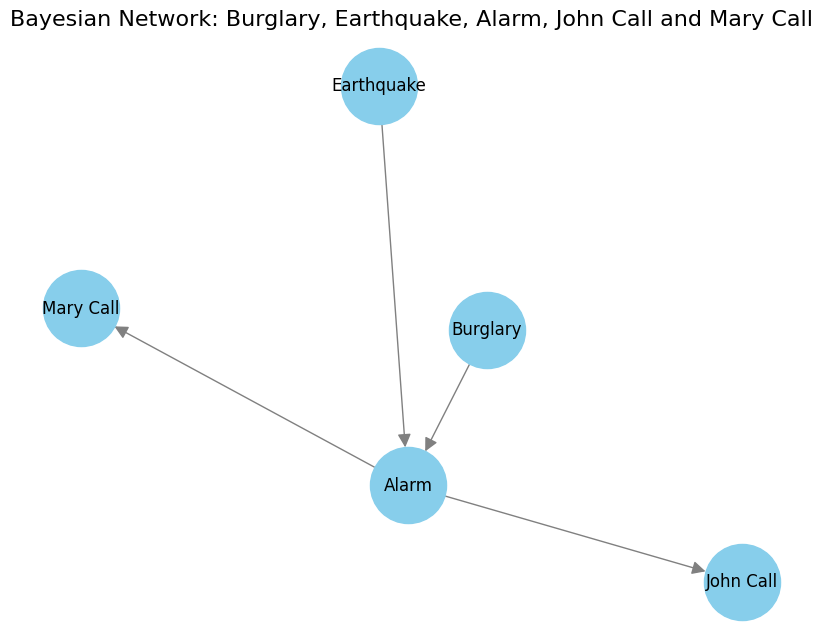

In [4]:
import matplotlib.pyplot as plt
import networkx as nx

# Create a NetworkX graph from the Bayesian Network
graph = nx.DiGraph()  
graph.add_edges_from(model.edges())  

# Plot the graph
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(graph) 
nx.draw(
    graph, pos,
    with_labels=True,
    node_size=3000,
    node_color='skyblue',
    font_size=12,
    font_color='black',
    arrowsize=20,
    edge_color='gray'
)
plt.title("Bayesian Network: Burglary, Earthquake, Alarm, John Call and Mary Call", fontsize=16)
plt.show()


## Probabilistic Inference

In [5]:
from pgmpy.inference import VariableElimination

inference = VariableElimination(model)
# P(John call), it will having 2 states (F, T)
p_john_call = inference.query(variables=["John Call"])
p_mary_call = inference.query(variables=["Mary Call"])
# P(John call | Alarm)
p_john_call_a = inference.query(variables=["John Call"],evidence={"Alarm":1})
# P(Alarm)
p_a = inference.query(variables=["Alarm"])
# P(Alarm | Earthquake and Burglary)
p_a_earthquake_burglary = inference.query(variables=["Alarm"],evidence={"Earthquake":1,"Burglary":1})

# joint probability
joint_p_a_earthquake_burglary_john_mary = (inference.query(variables=["Alarm"],evidence={"Earthquake":0,"Burglary":0}).values[1] * # P(A|-E,-B)
                                           inference.query(variables=["Burglary"]).values[0] * # P(-B)
                                           inference.query(variables=["John Call"],evidence={"Alarm":1}).values[1] * # P(J|A)
                                           inference.query(variables=["Mary Call"],evidence={"Alarm":1}).values[1]) # P(M|A)
p_burglary_john_mary_call = inference.query(variables=["Burglary"],evidence={"John Call":1,"Mary Call":1}) # P(B|J,M)
                                          
print("\nP(J):\n", p_john_call)
print("\nP(M):\n", p_mary_call)
print("\nP(J|A):\n", p_john_call_a)
print("\nP(A):\n", p_a)
print("\nP(A|E,B):\n", p_a_earthquake_burglary)
print("\nP(A,-E,-B,J,M):", joint_p_a_earthquake_burglary_john_mary)
#print("\n")
print("\nP(B|J,M):\n",p_burglary_john_mary_call)


P(J):
 +--------------+------------------+
| John Call    |   phi(John Call) |
+==============+==================+
| John Call(0) |           0.9479 |
+--------------+------------------+
| John Call(1) |           0.0521 |
+--------------+------------------+

P(M):
 +--------------+------------------+
| Mary Call    |   phi(Mary Call) |
+==============+==================+
| Mary Call(0) |           0.9883 |
+--------------+------------------+
| Mary Call(1) |           0.0117 |
+--------------+------------------+

P(J|A):
 +--------------+------------------+
| John Call    |   phi(John Call) |
+==============+==================+
| John Call(0) |           0.1000 |
+--------------+------------------+
| John Call(1) |           0.9000 |
+--------------+------------------+

P(A):
 +----------+--------------+
| Alarm    |   phi(Alarm) |
+==========+==============+
| Alarm(0) |       0.9975 |
+----------+--------------+
| Alarm(1) |       0.0025 |
+----------+--------------+

P(A|E,B):
 +-

## Causal Inference

In [6]:
model.add_cpds(TabularCPD(variable='Burglary', variable_card=2, values=[[0.0], [1.0]]))
p_john_call_burglary = inference.query(variables=["John Call"],evidence={"Burglary":1})
print(p_john_call_burglary)

+--------------+------------------+
| John Call    |   phi(John Call) |
+==============+==================+
| John Call(0) |           0.1510 |
+--------------+------------------+
| John Call(1) |           0.8490 |
+--------------+------------------+


## Exercises
1. Demonstrate the calculation of the probability that John call. <br>
2. Demonstrate the calculation of the probability that Mary call. <br>
3. Demonstrate the calculation of the probability that the alarm has occured but neither a burglary nor an earthquake has occured and both John and Mary call?
4. Demonstrate the calculation of the probability that there is a burglary given that John and Mary call?

# Unsupervised Learning Using Bayesian Network with Bayesian Information Criterion Score

In [7]:
from sklearn.datasets import load_iris
import pandas as pd
from pgmpy.estimators import HillClimbSearch, BicScore
from pgmpy.models import BayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from scipy.stats import chi2_contingency

# Load the Iris dataset
iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names)

# Discretize the data (necessary for Bayesian networks)
# Discretize using pandas qcut (quantile-based discretization)
# discretize data: convert continuous numerical data into discrete data
discretized_data = data.apply(lambda x: pd.qcut(x, q=3, labels=False))

# Perform structure learning using HillClimbSearch with BIC score
hc = HillClimbSearch(discretized_data)
best_model = hc.estimate(scoring_method=BicScore(discretized_data))

# Display the learned structure
print("Learned Structure:", best_model.edges())

# Fit parameters to the learned structure
model = BayesianNetwork(best_model.edges())
model.fit(discretized_data, estimator=MaximumLikelihoodEstimator)

# Display the learned CPDs
print("CPDs:")
for cpd in model.get_cpds():
    print(cpd)


  0%|          | 3/1000000 [00:00<2:40:40, 103.73it/s]

Learned Structure: [('petal length (cm)', 'sepal length (cm)'), ('petal width (cm)', 'petal length (cm)'), ('petal width (cm)', 'sepal width (cm)')]
CPDs:
+----------------------+-----+---------------------+
| petal width (cm)     | ... | petal width (cm)(2) |
+----------------------+-----+---------------------+
| petal length (cm)(0) | ... | 0.0                 |
+----------------------+-----+---------------------+
| petal length (cm)(1) | ... | 0.14583333333333334 |
+----------------------+-----+---------------------+
| petal length (cm)(2) | ... | 0.8541666666666666  |
+----------------------+-----+---------------------+
+----------------------+-----+----------------------+
| petal length (cm)    | ... | petal length (cm)(2) |
+----------------------+-----+----------------------+
| sepal length (cm)(0) | ... | 0.0                  |
+----------------------+-----+----------------------+
| sepal length (cm)(1) | ... | 0.30434782608695654  |
+----------------------+-----+--------------

## Visualize DAG

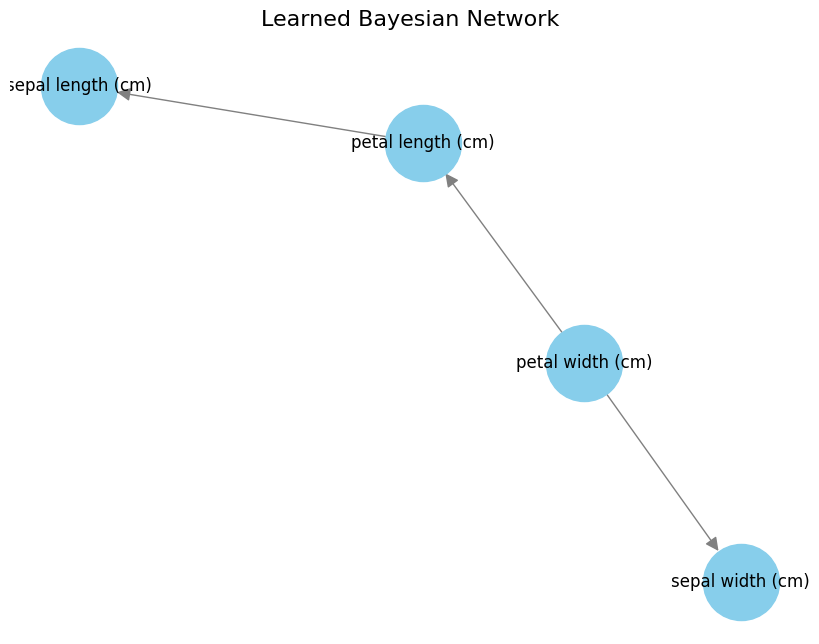

In [8]:
import matplotlib.pyplot as plt
import networkx as nx

# Create a NetworkX graph from the Bayesian Network
graph = nx.DiGraph()  
graph.add_edges_from(model.edges()) 

# Plot the graph
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(graph) 
nx.draw(
    graph, pos,
    with_labels=True,
    node_size=3000,
    node_color='skyblue',
    font_size=12,
    font_color='black',
    arrowsize=20,
    edge_color='gray'
)
plt.title("Learned Bayesian Network", fontsize=16)
plt.show()